<a href="https://colab.research.google.com/github/m4tss0/Calculo-Numerico-2026-2/blob/main/Atividade_2_C%C3%A1lculo_Num%C3%A9rico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 2 - Cálculo Numérico

**Nome:** Mateus de Lima Alencar Soares  
**RA:** 185301  
**Turma:** Noturno  


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 500 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 500 passos sem overflow.
dt=0.002, float64: 500 passos sem overflow.


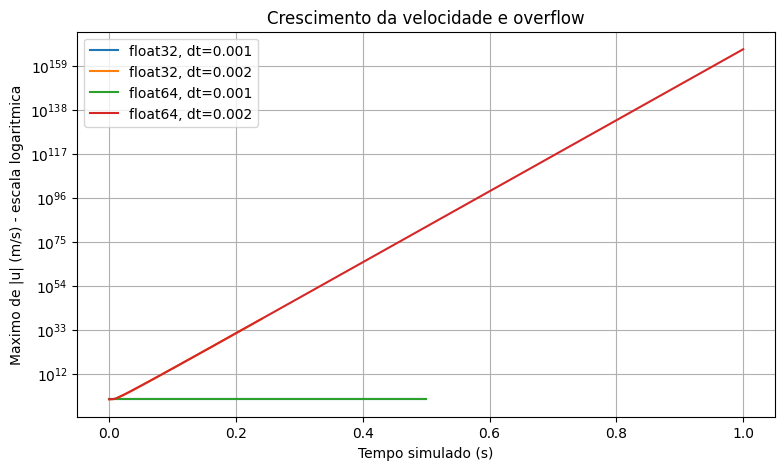

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=500, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## 1 - Verificação da Estabilidade:

In [16]:
# Parâmetros fornecidos no roteiro
H = 0.01          # Distância entre as placas (m)
nu = 1e-4         # Viscosidade cinemática (m²/s)
pontos = 21       # Número total de pontos na malha

# 1. Cálculo do espaçamento espacial (dy)
dy = H / (pontos - 1)

# 2. Cálculo do passo de tempo crítico máximo (dt_max)
dt_max = (dy**2) / (2 * nu)

# Definição dos casos A e B
casos = {
    "Caso A": 0.001,
    "Caso B": 0.002
}

print(f"Espaçamento espacial (Δy): {dy:.6f} m")
print(f"Passo de tempo máximo estável (Δt_max): {dt_max:.6f} s\n")

# 3. Cálculo de r e verificação de estabilidade
for nome, dt in casos.items():
    r = (nu * dt) / (dy**2)
    estavel = r <= 0.5
    status = "ESTÁVEL (r <= 0.5)" if estavel else "INSTÁVEL (r > 0.5)"
    print(f"{nome}: Δt = {dt} s | r = {r:.2f} -> {status}")

Espaçamento espacial (Δy): 0.000500 m
Passo de tempo máximo estável (Δt_max): 0.001250 s

Caso A: Δt = 0.001 s | r = 0.40 -> ESTÁVEL (r <= 0.5)
Caso B: Δt = 0.002 s | r = 0.80 -> INSTÁVEL (r > 0.5)


## 2 - Detecção de Overflow:

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=1000, pontos=21):
    """Simula a difusão de velocidade e detecta falhas por overflow."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numérico escolhido
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Condição inicial e de contorno
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1.0)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Converte avisos de ponto flutuante em exceções capturáveis
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualização espacial (diferenças finitas)
                novo[1:-1] = u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2])
                u = novo
            except FloatingPointError as erro:
                falha = passo
                print(f"Δt={dt}s, {tipo.__name__}: Falha por overflow no passo {passo} (t = {passo*dt:.4f} s)")
                break

            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"Δt={dt}s, {tipo.__name__}: Concluído com sucesso ({passos} passos sem overflow).")

    return {
        "tipo": tipo.__name__,
        "dt": dt,
        "r": float(r),
        "overflow": "Sim" if falha is not None else "Não",
        "iteracao_falha": falha if falha is not None else "N/A (estável)",
        "tempo_falha": f"{falha * dt:.4f} s" if falha is not None else "N/A",
        "tempos": tempos,
        "maximos": maximos,
        "u": u,
        "y": y
    }

# Execução das 4 combinações
dados_tabela = []
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        res = simular(dt, tipo=tipo, passos=1000, pontos=21)
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = res
        dados_tabela.append({
            "Tipo Numérico": res["tipo"],
            "Passo de Tempo (Δt)": f"{res['dt']} s",
            "Valor de r": f"{res['r']:.2f}",
            "Ocorrência de Overflow": res["overflow"],
            "Iteração da Falha": res["iteracao_falha"]
        })

# Exibição da tabela formatada
df_resultado = pd.DataFrame(dados_tabela)
print("\n--- TABELA DE RESULTADOS ---")
display(df_resultado)

Δt=0.001s, float32: Concluído com sucesso (1000 passos sem overflow).
Δt=0.002s, float32: Falha por overflow no passo 121 (t = 0.2420 s)
Δt=0.001s, float64: Concluído com sucesso (1000 passos sem overflow).
Δt=0.002s, float64: Falha por overflow no passo 917 (t = 1.8340 s)

--- TABELA DE RESULTADOS ---


,Tipo Numérico,Passo de Tempo (Δt),Valor de r,Ocorrência de Overflow,Iteração da Falha
0,float32,0.001 s,0.40,Não,N/A (estável)
1,float32,0.002 s,0.80,Sim,121
2,float64,0.001 s,0.40,Não,N/A (estável)
3,float64,0.002 s,0.80,Sim,917


## 3 - Interpretação Física:

  Ao analisar a reta no gráfico semilogarítmico, nota-se que o crescimento no caso instável (r = 0,80) apresenta um crescimento exponencial que viola a física do problema tratado. Uma vez que a única fonte de movimento é a placa inferior com deslocamento 1m/s, as camadas do fluído deveriam permanecer em qualquer velocidade na faixa de 0 a 1m/s. No entanto, na escolha de r > 0,5, assim como atestado, leva a um coeficiente negativo no cálculo da média ponderada na equação da condição de estabilidade, levando a erros e crescimentos até um possível overflow, os quais foram atestados no gráfico, pois a partir de 20 passos realizados, a velocidade do fluído ultrapassa 1m/s e torna-se uma representação falha da realidade física.

## 4 - Capacidade de Representação:

  Ao comparar os testes no caso instável ($\Delta t = 0{,}002\text{ s}$, $r = 0{,}80$), realizados no item 2, observa-se que a troca de float32 para float64 não elimina a instabilidade numérica, apenas adia o momento em que o overflow é detectado, sendo na iteração n° 121, para float32 ou na iteração n° 917, no float64.
  
  Como r > 0,5 causa uma falha intrínseca à fórmula, a representação numérica máxima do ponto flutuante não a extinguiria,  

## 5 - Refinamento da Malha:


In [41]:
# 1. Cálculos teóricos da nova malha
H = 0.01
nu = 1e-4
pontos_ref = 41

dy_ref = H / (pontos_ref - 1)
dt_max_ref = (dy_ref**2) / (2 * nu)

print(f"Novo Δy (41 pontos): {dy_ref:.6f} m")
print(f"Novo Δt_max crítico: {dt_max_ref:.7f} s\n")

# 2. Teste inicial com dt = 0.001 s (instável na malha fina)
print("--- Teste 1: Malha de 41 pontos com Δt = 0.001 s ---")
res_instavel_ref = simular(dt=0.001, tipo=np.float64, passos=2000, pontos=41)

# 3. Teste corrigido com novo dt estável (escolhendo dt = 0.00025 s)
dt_estavel_ref = 0.00025
print(f"\n--- Teste 2: Malha de 41 pontos com Δt corrigido = {dt_estavel_ref} s ---")
res_estavel_ref = simular(dt=dt_estavel_ref, tipo=np.float64, passos=2000, pontos=41)

Novo Δy (41 pontos): 0.000250 m
Novo Δt_max crítico: 0.0003125 s

--- Teste 1: Malha de 41 pontos com Δt = 0.001 s ---
Δt=0.001s, float64: Falha por overflow no passo 426 (t = 0.4260 s)

--- Teste 2: Malha de 41 pontos com Δt corrigido = 0.00025 s ---
Δt=0.00025s, float64: Concluído com sucesso (2000 passos sem overflow).


## 6 - Verificação do perfil de velocidade:

Δt=1e-05s, float64: Concluído com sucesso (20000 passos sem overflow).
Tempo total simulado: 0.20 s
Erro máximo em relação ao estacionário (E_inf): 8.860168e-02 m/s


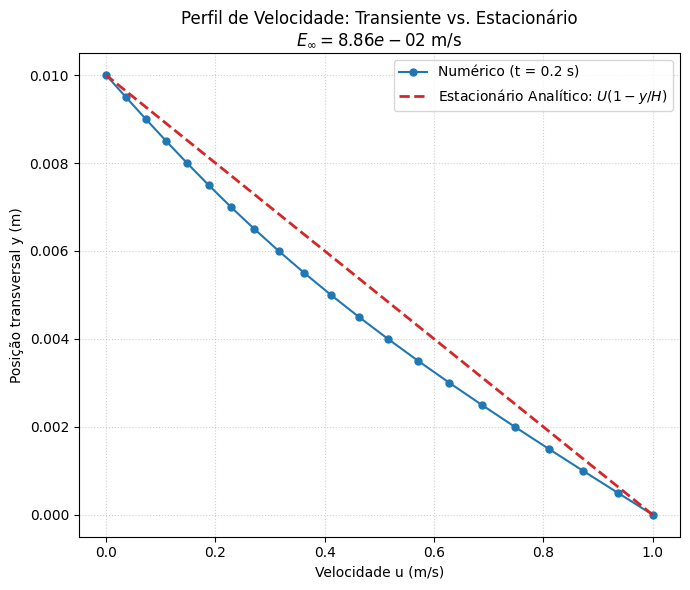

In [64]:
# 1. Recupera o resultado da simulação estável (Caso A: dt = 0.001 s, 21 pontos)
# Caso queira rodar diretamente:
res_estavel = simular(dt=0.00001, tipo=np.float64, passos=20000, pontos=21)

y = res_estavel["y"]
u_numerico = res_estavel["u"]
tempo_total = res_estavel["tempos"][-1]

# 2. Solução analítica estacionária (escoamento linear de Couette)
H = 0.01
U = 1.0
u_est = U * (1.0 - y / H)

# 3. Cálculo da diferença máxima (Norma do Máximo / Erro Infinito)
E_inf = np.max(np.abs(u_numerico - u_est))

print(f"Tempo total simulado: {tempo_total:.2f} s")
print(f"Erro máximo em relação ao estacionário (E_inf): {E_inf:.6e} m/s")

# 4. Representação gráfica comparativa
plt.figure(figsize=(7, 6))
plt.plot(u_numerico, y, 'o-', color='tab:blue', label=f'Numérico (t = {tempo_total:.1f} s)', markersize=5)
plt.plot(u_est, y, '--', color='tab:red', label='Estacionário Analítico: $U(1 - y/H)$', linewidth=2)

plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição transversal y (m)")
plt.title(f"Perfil de Velocidade: Transiente vs. Estacionário\n$E_\\infty = {E_inf:.2e}$ m/s")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Ao avaliar a convergência para o regime estacionário, percebe-se que o alcance do equilíbrio não se deve apenas do número de iterações, mas também do tempo total acumulado pela simulação ($t = \text{passos} \times \Delta t$) em relação à escala de tempo da difusão viscosa do escoamento. Tal constatação é observada ao realizar testes nos valores para geração do gráfico, no qual nota-se que uma quantidade elevada de passos ainda pode se encontrar retida na fase transiente se o $\Delta t$ for excessivamente pequeno. Porém, desde que a estabilidade numérica mantida ($r \le 0{,}50$), há garantia da conclusão dos efeitos transientes e a convergência para a linearidade estacionária.  

## 7 - Conclusão:

Em suma, tornou-se evidente que instabilidade matemática e overflow são fenômenos distintos: Durante a análise do problema foi comprovado o resultado esperado para os dois intervalos de r, sendo que para r < 0,5, notou-se a limitação da máquina no tratamento de problemas físicos quando transpostos apenas para dados gráficos. Além disso, ficou evidente que a diferença de float32 para float64 não impede o overflow, apenas o adia e aumenta o intervalo de representação numérica dos pontos flutuantes. Ademais, através da combinação dos conhecimentos adquiridos, é possível realizar o refinamento da malha de análise, de modo a garantir uma simulação estável e equilibrada (convergência do estado transiente para estacionário) ao manipular os dados das equações obtidas.